In [33]:
## Setup & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [34]:
# Load the dataset
FILE_PATH = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(FILE_PATH)
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [35]:
## Data Exploration

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [37]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts().head(10))

Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

--- Farm_ID (4000 unique values) ---
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
Name: count, dtype: int64

--- State (8 unique values) ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District (10 unique values) ---
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop (8 unique values) ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season (3 unique values) ---

In [38]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {df.isnull().sum().sum()} out of {df.shape[0]*df.shape[1]}")

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 out of 112000


In [39]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm IDs:", df['Farm_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Farm IDs: 0


In [40]:
## Data Cleaning & Preparation

df_clean = df.copy()

num_cols_with_na = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in num_cols_with_na:
    df_clean[col] = df_clean.groupby(['Season', 'Crop'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    # fallback: fill any remaining NaNs (rare edge cases) with overall median
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())

Remaining missing values after imputation:
0


In [41]:
checks = {
    'Soil_pH': (0, 14),
    'Humidity_pct': (0, 100),
    'Disease_Pest_Risk_pct': (0, 100),
}
for col, (lo, hi) in checks.items():
    out_of_range = df_clean[(df_clean[col] < lo) | (df_clean[col] > hi)]
    print(f"{col}: {len(out_of_range)} rows out of expected range [{lo}, {hi}]")

Soil_pH: 0 rows out of expected range [0, 14]
Humidity_pct: 0 rows out of expected range [0, 100]
Disease_Pest_Risk_pct: 0 rows out of expected range [0, 100]


In [42]:
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR'].replace(0, np.nan)) * 100
df_clean['Cost_per_Hectare'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Revenue_per_Hectare'] = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']
season_order = ['Kharif', 'Rabi', 'Zaid']
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=season_order, ordered=True)

df_clean.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,80494.339623,58132.075472
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,75398.315467,6186.983155
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,64858.024691,39190.534979
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,65876.444444,44608.888889
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,80275.296912,45987.410926


In [43]:
## Seasonal Performance Comparison

performance_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Profit_Margin_pct', 'Revenue_per_Hectare']
seasonal_performance = df_clean.groupby('Season')[performance_cols].mean().round(2)
seasonal_performance

/tmp/ipykernel_671/2744228953.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_performance = df_clean.groupby('Season')[performance_cols].mean().round(2)


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Profit_Margin_pct,Revenue_per_Hectare
Season,,,,,
Kharif,5.63,46.31,178914.65,-38.64,88782.79
Rabi,5.09,41.49,87689.47,-44.27,76656.92
Zaid,4.64,38.89,-24804.82,-69.35,64301.42


/tmp/ipykernel_671/702349198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette='YlGn')
/tmp/ipykernel_671/702349198.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', ax=axes[0,1], palette='YlOrBr')
/tmp/ipykernel_671/702349198.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', ax=axes[1,0],
/tmp/ipykernel_671/702349198.py:13: FutureWarning: 

Passing `palette` without assignin

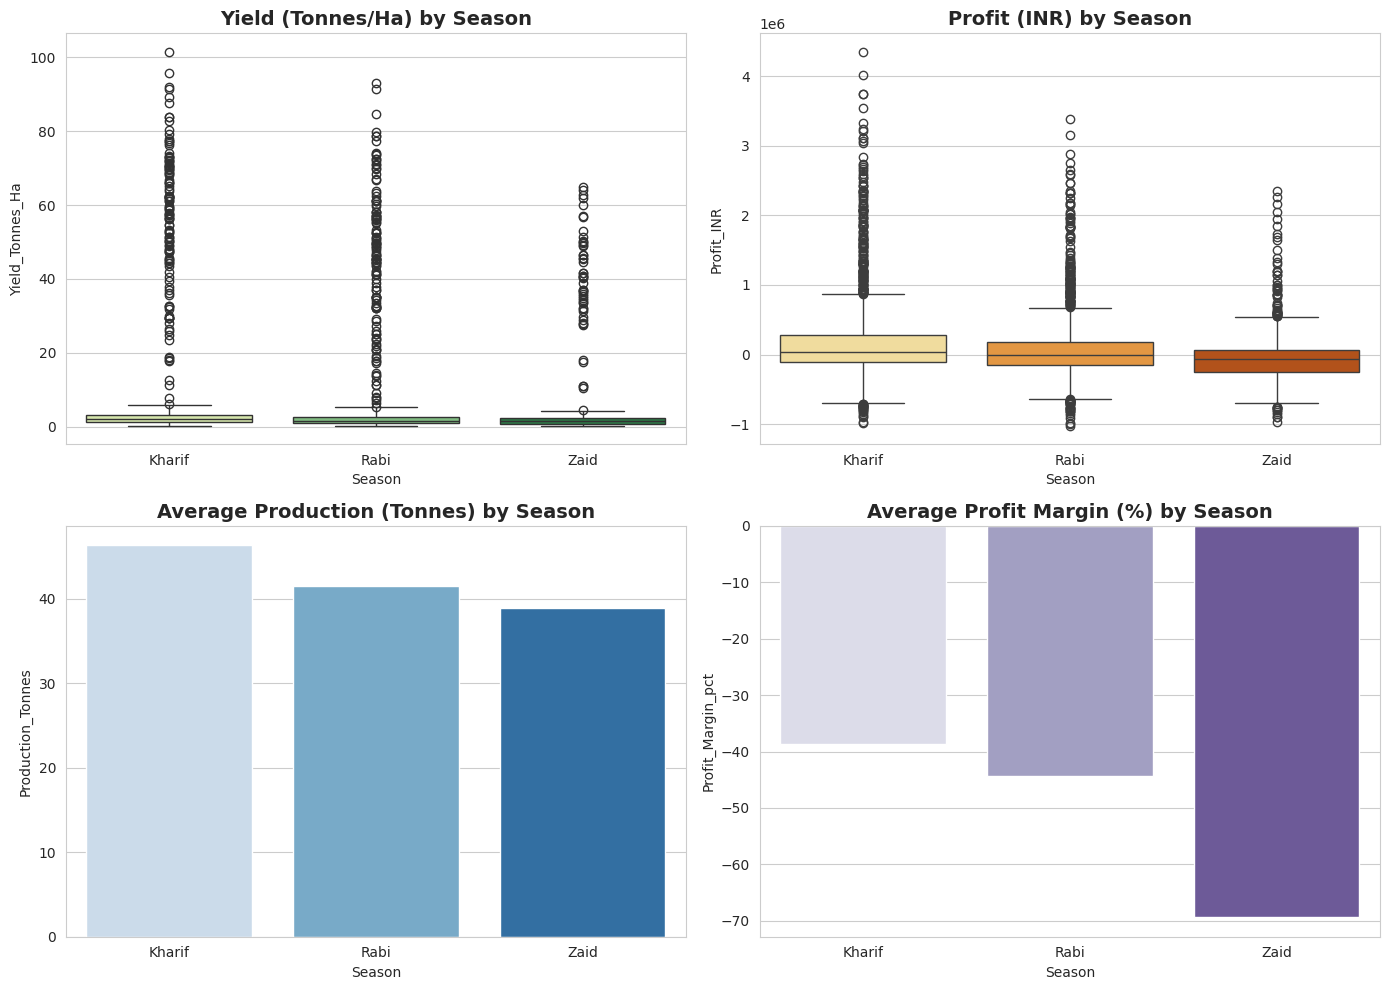

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette='YlGn')
axes[0,0].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', ax=axes[0,1], palette='YlOrBr')
axes[0,1].set_title('Profit (INR) by Season')

sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', ax=axes[1,0],
            estimator=np.mean, palette='Blues', errorbar=None)
axes[1,0].set_title('Average Production (Tonnes) by Season')

sns.barplot(data=df_clean, x='Season', y='Profit_Margin_pct', ax=axes[1,1],
            estimator=np.mean, palette='Purples', errorbar=None)
axes[1,1].set_title('Average Profit Margin (%) by Season')

plt.tight_layout()
plt.show()

In [45]:
## Seasonal Patterns in Environmental Conditions

env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
seasonal_env = df_clean.groupby('Season')[env_cols].mean().round(2)
seasonal_env

/tmp/ipykernel_671/822786029.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_env = df_clean.groupby('Season')[env_cols].mean().round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


/tmp/ipykernel_671/152319468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_671/152319468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_671/152319468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_671/152319468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is 

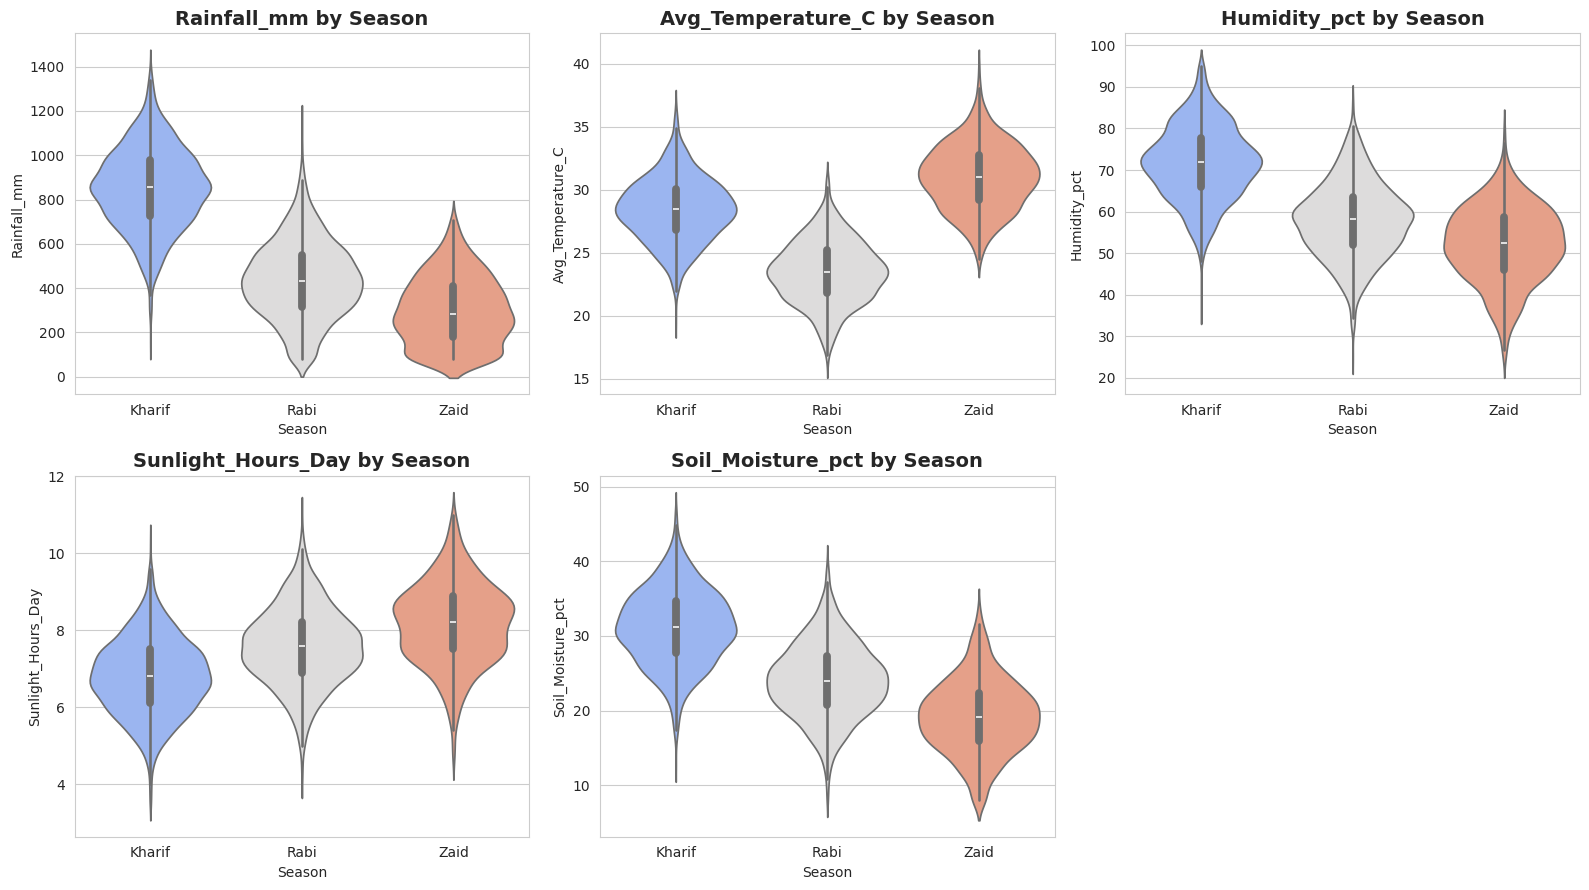

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(env_cols):
    sns.violinplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Season')

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.show()

In [47]:
## Resource Usage Across Seasons

resource_cols = ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']
seasonal_resources = df_clean.groupby('Season')[resource_cols].mean().round(2)
seasonal_resources


/tmp/ipykernel_671/447280479.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_resources = df_clean.groupby('Season')[resource_cols].mean().round(2)


,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


/tmp/ipykernel_671/3115415262.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Water_Used_m3', ax=axes[0], estimator=np.mean,
/tmp/ipykernel_671/3115415262.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1], estimator=np.mean,
/tmp/ipykernel_671/3115415262.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Fertilizer_kg_ha', ax=axes[2], estimator=np.mean,


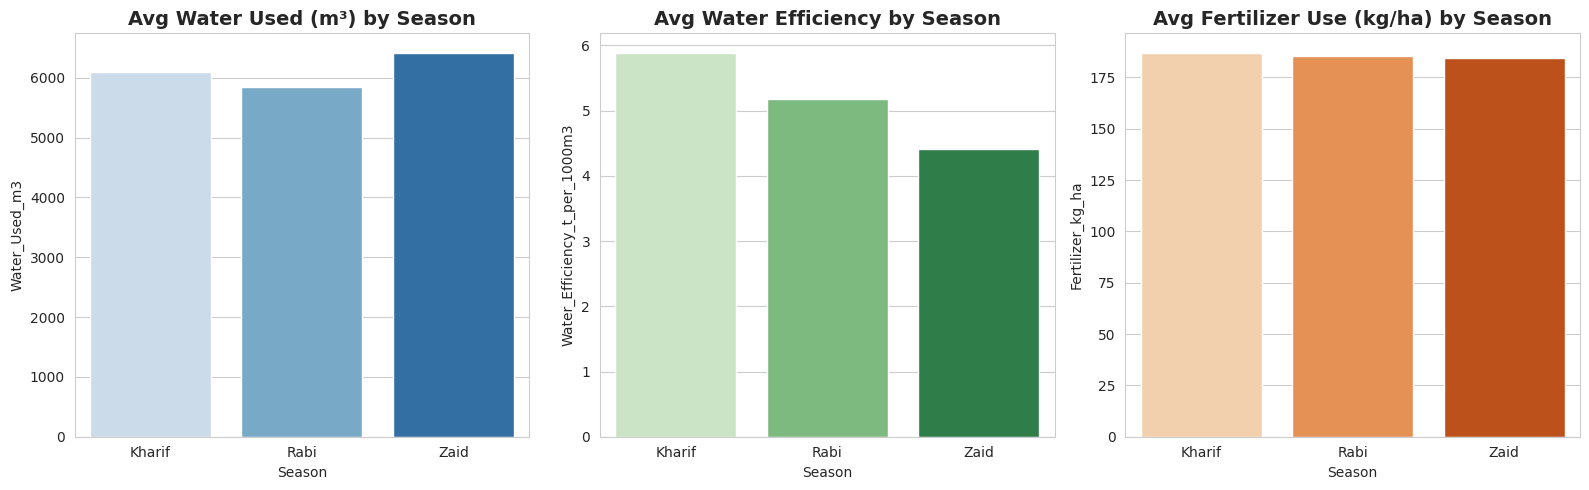

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df_clean, x='Season', y='Water_Used_m3', ax=axes[0], estimator=np.mean,
            palette='Blues', errorbar=None)
axes[0].set_title('Avg Water Used (m³) by Season')

sns.barplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1], estimator=np.mean,
            palette='Greens', errorbar=None)
axes[1].set_title('Avg Water Efficiency by Season')

sns.barplot(data=df_clean, x='Season', y='Fertilizer_kg_ha', ax=axes[2], estimator=np.mean,
            palette='Oranges', errorbar=None)
axes[2].set_title('Avg Fertilizer Use (kg/ha) by Season')

plt.tight_layout()
plt.show()


In [49]:
irrigation_season = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method'], normalize='index') * 100
irrigation_season.round(1)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


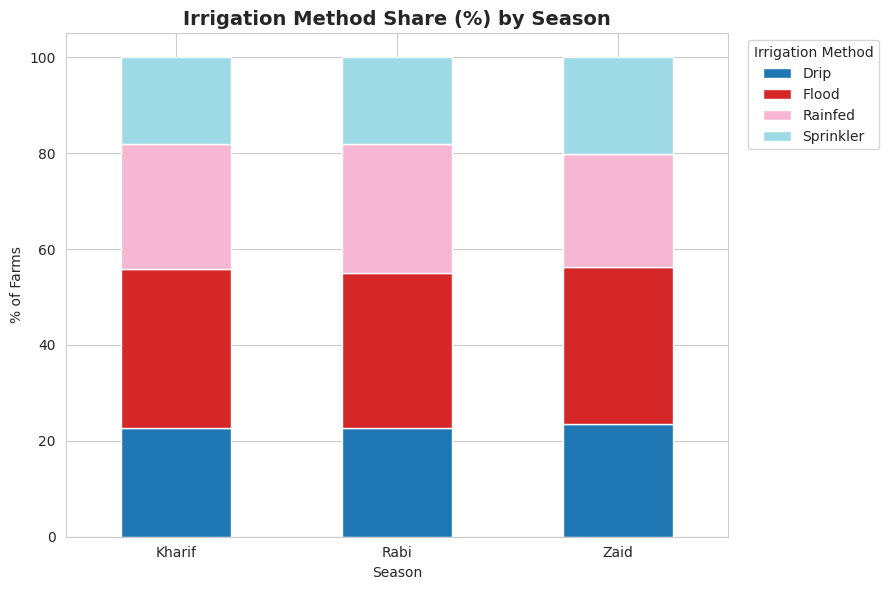

In [50]:
irrigation_season.plot(kind='bar', stacked=True, figsize=(9,6), colormap='tab20')
plt.title('Irrigation Method Share (%) by Season')
plt.ylabel('% of Farms')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

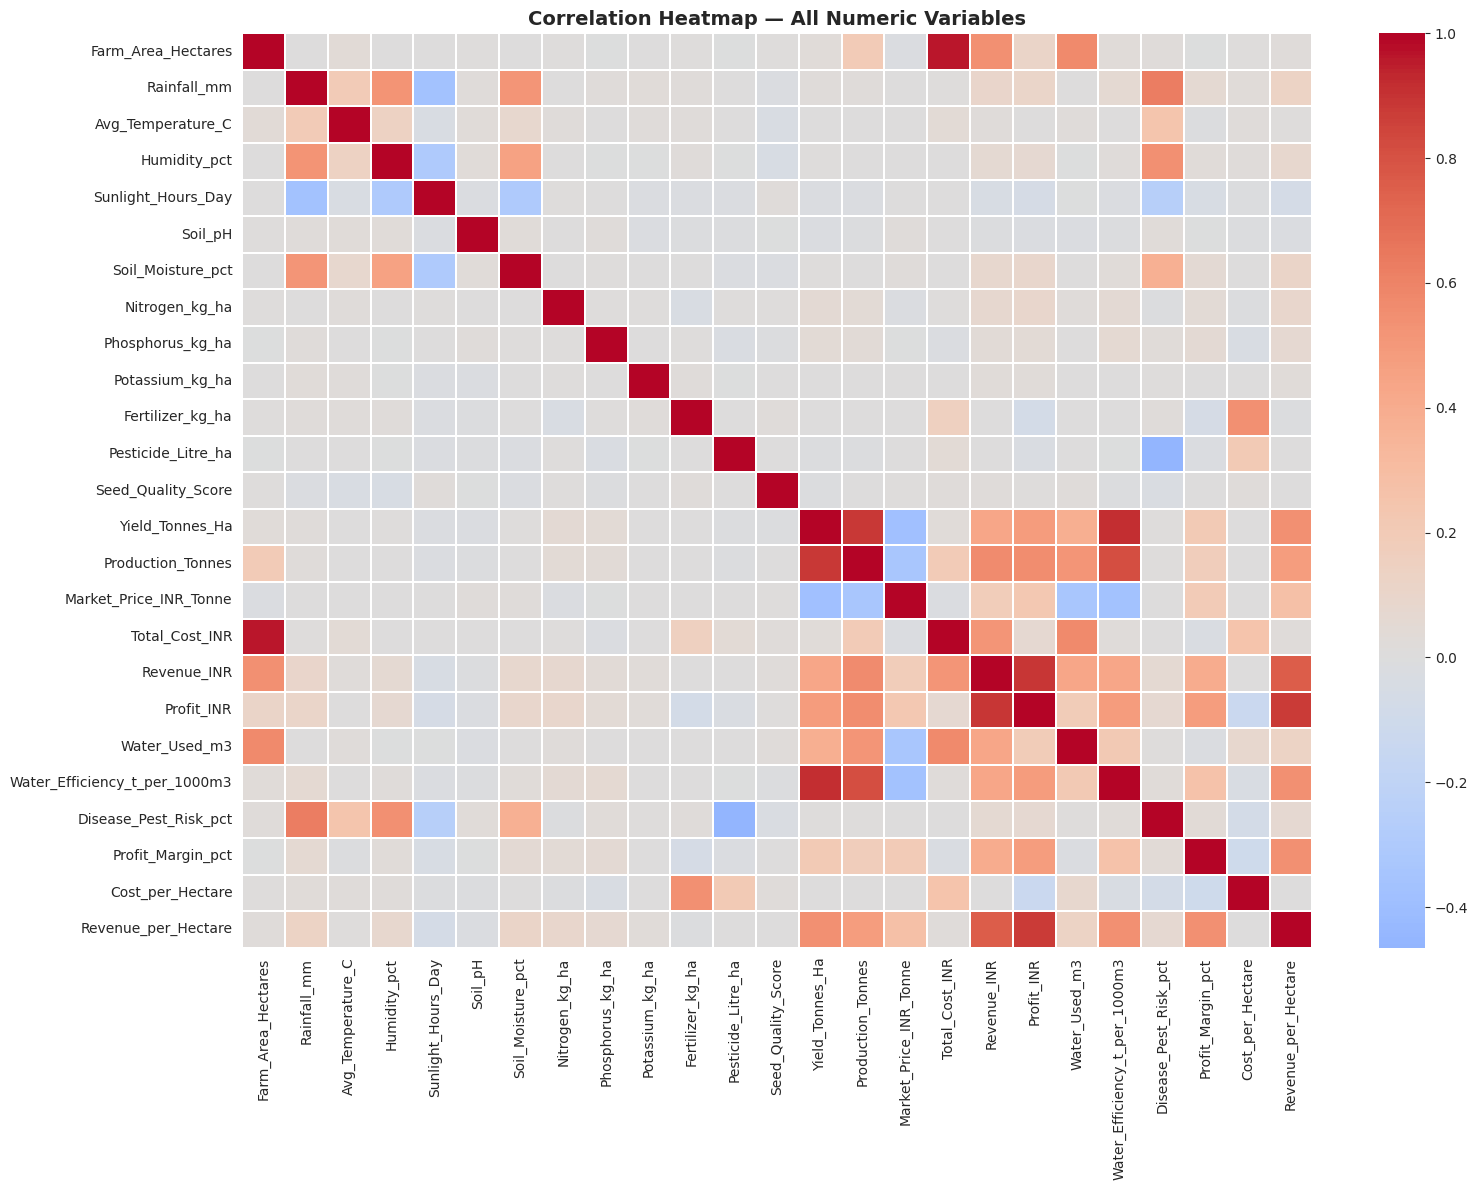

In [51]:
## Relationships Between Environmental Conditions & Performance

numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — All Numeric Variables')
plt.tight_layout()
plt.show()


In [52]:
target_corr = corr[['Yield_Tonnes_Ha', 'Profit_INR']].sort_values('Yield_Tonnes_Ha', ascending=False)
target_corr

,Yield_Tonnes_Ha,Profit_INR
Yield_Tonnes_Ha,1.000000,0.489350
Water_Efficiency_t_per_1000m3,0.915517,0.489487
Production_Tonnes,0.885442,0.554172
Revenue_per_Hectare,0.542872,0.875800
Profit_INR,0.489350,1.000000
Revenue_INR,0.433033,0.887331
Water_Used_m3,0.387373,0.190278
Profit_Margin_pct,0.205448,0.481375
Nitrogen_kg_ha,0.053633,0.085016
Phosphorus_kg_ha,0.046685,0.049747


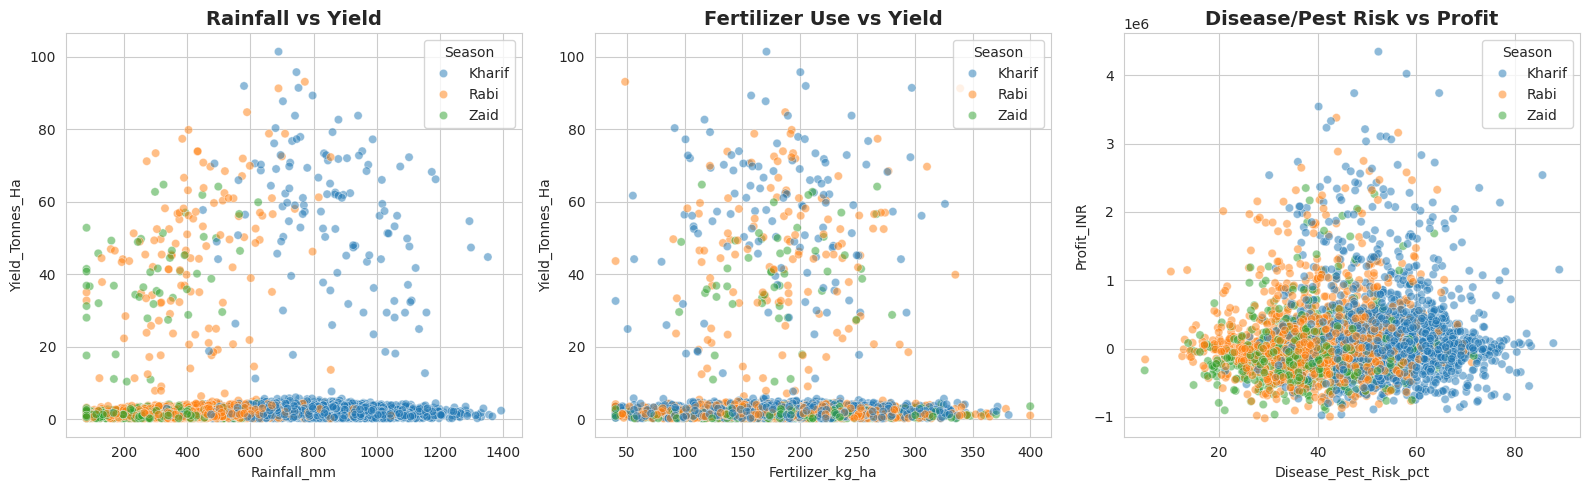

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df_clean, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[1])
axes[1].set_title('Fertilizer Use vs Yield')

sns.scatterplot(data=df_clean, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season', alpha=0.5, ax=axes[2])
axes[2].set_title('Disease/Pest Risk vs Profit')

plt.tight_layout()
plt.show()

In [55]:
## Regional & Crop-wise Seasonal Consistency
# Average yield by State and Season (pivot table)
state_season_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean').round(2)
state_season_yield

/tmp/ipykernel_671/1904760949.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  state_season_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean').round(2)


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.67,4.07
Karnataka,6.46,4.78,6.62
Madhya Pradesh,5.99,3.76,5.46
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.80,4.24


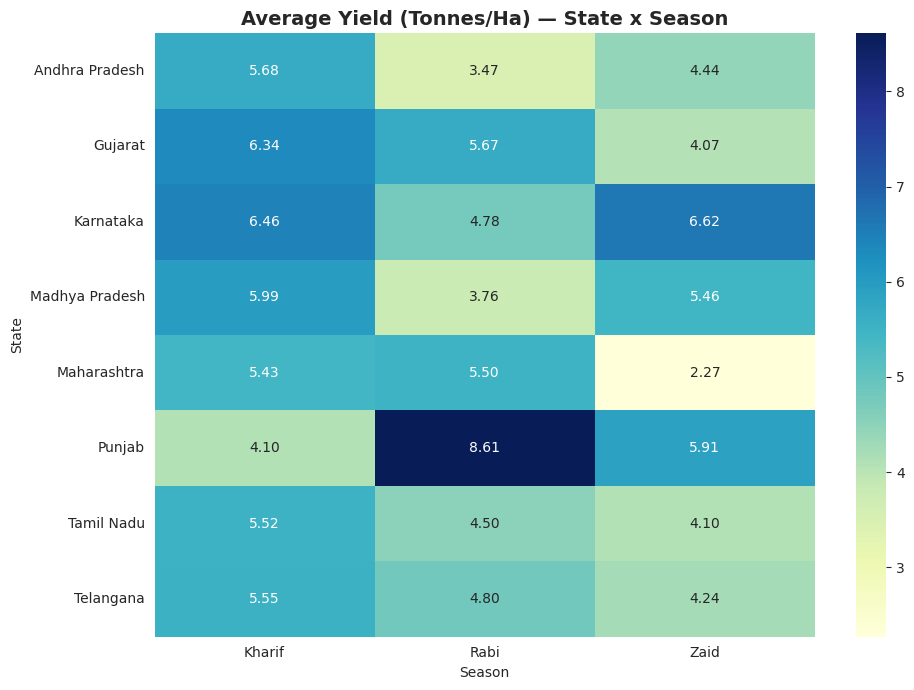

In [56]:
plt.figure(figsize=(10, 7))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield (Tonnes/Ha) — State x Season')
plt.tight_layout()
plt.show()

In [57]:
crop_season_profit = df_clean.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean').round(0)
crop_season_profit

/tmp/ipykernel_671/1994530417.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  crop_season_profit = df_clean.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean').round(0)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


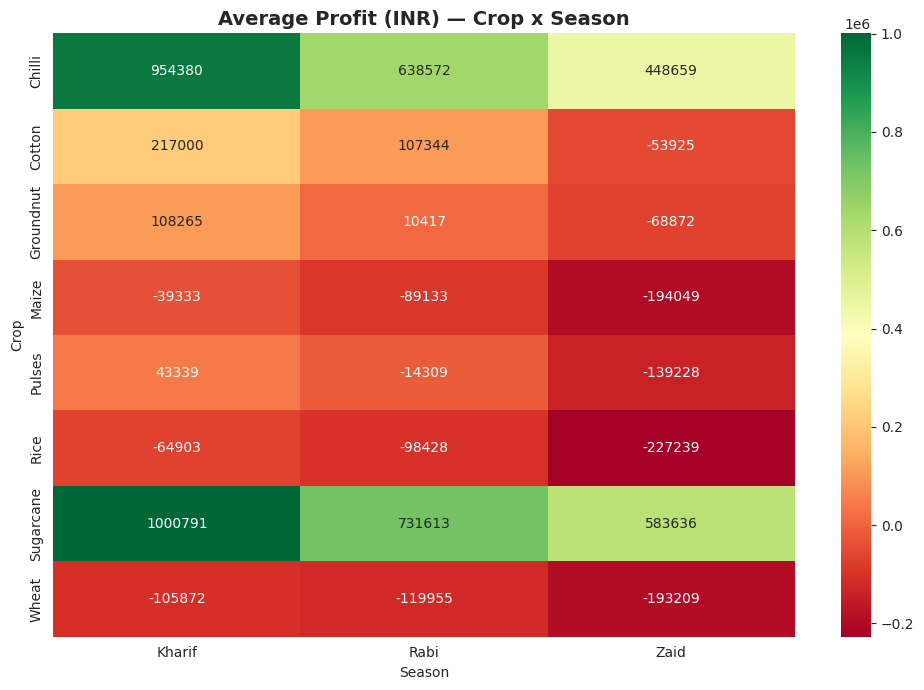

In [58]:
plt.figure(figsize=(10, 7))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn')
plt.title('Average Profit (INR) — Crop x Season')
plt.tight_layout()
plt.show()

In [59]:
## Statistical Significance Testing

from scipy.stats import f_oneway

def anova_by_season(df, col):
    groups = [group[col].dropna().values for _, group in df.groupby('Season', observed=True)]
    f_stat, p_val = f_oneway(*groups)
    return f_stat, p_val

for metric in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']:
    f_stat, p_val = anova_by_season(df_clean, metric)
    significance = "Statistically significant (p < 0.05)" if p_val < 0.05 else "Not statistically significant (p >= 0.05)"
    print(f"{metric}: F = {f_stat:.3f}, p = {p_val:.5f}  -->  {significance}")

Yield_Tonnes_Ha: F = 1.458, p = 0.23285  -->  Not statistically significant (p >= 0.05)
Profit_INR: F = 34.292, p = 0.00000  -->  Statistically significant (p < 0.05)
Water_Efficiency_t_per_1000m3: F = 6.948, p = 0.00097  -->  Statistically significant (p < 0.05)


In [60]:
r, p = stats.pearsonr(df_clean['Rainfall_mm'], df_clean['Yield_Tonnes_Ha'])
print(f"Rainfall vs Yield: r = {r:.3f}, p = {p:.5f}")

r2, p2 = stats.pearsonr(df_clean['Fertilizer_kg_ha'], df_clean['Yield_Tonnes_Ha'])
print(f"Fertilizer vs Yield: r = {r2:.3f}, p = {p2:.5f}")

Rainfall vs Yield: r = 0.027, p = 0.08943
Fertilizer vs Yield: r = -0.000, p = 0.97911


In [61]:
## Outlier & Unusual Pattern Detection
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lower) | (series > upper)

df_clean['Is_Profit_Outlier'] = df_clean.groupby('Season', observed=True)['Profit_INR'].transform(iqr_outliers)

outlier_summary = df_clean.groupby('Season', observed=True)['Is_Profit_Outlier'].sum()
print("Number of profit outliers per season:")
print(outlier_summary)

Number of profit outliers per season:
Season
Kharif    184
Rabi      174
Zaid       64
Name: Is_Profit_Outlier, dtype: int64


In [62]:
df_clean['Is_Loss'] = df_clean['Profit_INR'] < 0
loss_rate = df_clean.groupby('Season', observed=True)['Is_Loss'].mean() * 100
print("Percentage of farms operating at a loss, by season:")
print(loss_rate.round(1))

Percentage of farms operating at a loss, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss, dtype: float64


/tmp/ipykernel_671/259986557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_rate.index, y=loss_rate.values, palette='Reds')


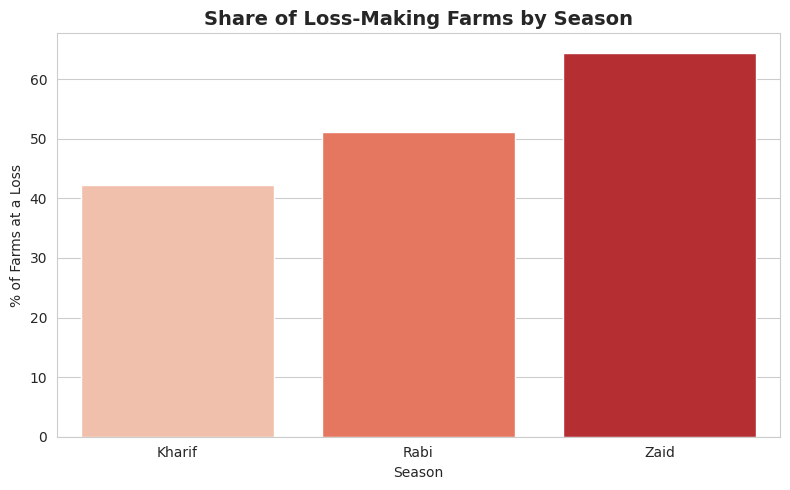

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x=loss_rate.index, y=loss_rate.values, palette='Reds')
plt.ylabel('% of Farms at a Loss')
plt.title('Share of Loss-Making Farms by Season')
plt.tight_layout()
plt.show()

In [64]:
## Summary

best_yield_season = seasonal_performance['Yield_Tonnes_Ha'].idxmax()
best_profit_season = seasonal_performance['Profit_INR'].idxmax()
worst_profit_season = seasonal_performance['Profit_INR'].idxmin()
highest_loss_season = loss_rate.idxmax()
most_water_efficient_season = seasonal_resources['Water_Efficiency_t_per_1000m3'].idxmax()

print("KEY INSIGHTS (auto-generated draft — refine with your own observations)")
print("-" * 70)
print(f"1. Highest average yield observed in: {best_yield_season} season")
print(f"2. Highest average profit observed in: {best_profit_season} season")
print(f"3. Lowest average profit observed in: {worst_profit_season} season")
print(f"4. Highest share of loss-making farms in: {highest_loss_season} season "
      f"({loss_rate[highest_loss_season]:.1f}% of farms)")
print(f"5. Best water-use efficiency observed in: {most_water_efficient_season} season")
print(f"6. Rainfall-Yield correlation: r = {r:.2f} "
      f"({'positive' if r > 0 else 'negative'} relationship, "
      f"{'significant' if p < 0.05 else 'not significant'})")
print(f"7. Fertilizer-Yield correlation: r = {r2:.2f} "
      f"({'positive' if r2 > 0 else 'negative'} relationship, "
      f"{'significant' if p2 < 0.05 else 'not significant'})")

KEY INSIGHTS (auto-generated draft — refine with your own observations)
----------------------------------------------------------------------
1. Highest average yield observed in: Kharif season
2. Highest average profit observed in: Kharif season
3. Lowest average profit observed in: Zaid season
4. Highest share of loss-making farms in: Zaid season (64.5% of farms)
5. Best water-use efficiency observed in: Kharif season
6. Rainfall-Yield correlation: r = 0.03 (positive relationship, not significant)
7. Fertilizer-Yield correlation: r = -0.00 (negative relationship, not significant)
